In [1]:
import subprocess
subprocess.check_call(["python", "-m", "pip", "install", "pandas"])

0

In [20]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HotelBigDataSQL") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

# 1. Đọc file dữ liệu từ kho Hadoop HDFS
df = spark.read.csv("hdfs://localhost:9000/user/hotel/data/hotel_bookings.csv", header=True, inferSchema=True)

# 2. In ra kích thước
print("Số lượng mẫu tin (Rows):", df.count())
print("Số lượng thuộc tính (Columns):", len(df.columns))

Số lượng mẫu tin (Rows): 119390
Số lượng thuộc tính (Columns): 32


In [3]:
!pip3 install numpy

In [21]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

spark = SparkSession.builder.appName("Preprocessing_Hotel_Data").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.csv("hdfs://localhost:9000/user/hotel/data/hotel_bookings.csv", header=True, inferSchema=True)

# # 1. Ép kiểu dữ liệu
# df = df.withColumn("children", df["children"].cast("int"))
# df = df.withColumn("adr", df["adr"].cast("double"))
# Thay 'NA' thành null trước, rồi mới cast + fill
df = df.withColumn("children", 
    when(col("children") == "NA", None)
    .otherwise(col("children").cast("int"))
)
df = df.withColumn("adr", df["adr"].cast("double"))

# # 2. Xử lý missing value VÀ LỌC BỎ CÁC "DÒNG MA" CỦA HADOOP
df_cleaned = df.na.fill({"children": 0, "country": "Unknown"})
df_cleaned = df_cleaned.dropna() # <--- "Bùa hộ mệnh" trị dứt điểm lỗi NA

# 3. Định nghĩa các nhóm biến
categorical_cols = ["hotel", "meal", "deposit_type", "customer_type"]
#numerical_cols = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "adr"]
numerical_cols = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
                  "previous_cancellations", "total_of_special_requests", "adr"]

# 4. Xây dựng cấu phần của Pipeline
indexers = [StringIndexer(inputCol=col, outputCol=col+"_index", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_index", outputCol=col+"_vec") for col in categorical_cols]

assembler_inputs = [col+"_vec" for col in categorical_cols] + numerical_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=False)

# 5. Lắp ráp và chạy Pipeline
pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])
pipeline_model = pipeline.fit(df_cleaned)
preprocessed_df = pipeline_model.transform(df_cleaned)

# 6. Chia tập Train/Test
train_df, test_df = preprocessed_df.randomSplit([0.8, 0.2], seed=42)

print("Cấu trúc dữ liệu sau khi tiền xử lý (Mẫu tin đầu tiên):")
preprocessed_df.select("features", "is_canceled").show(1, truncate=False)

print(f"Số lượng mẫu tin tập huấn luyện (Train): {train_df.count()}")
print(f"Số lượng mẫu tin tập kiểm thử (Test): {test_df.count()}")

Cấu trúc dữ liệu sau khi tiền xử lý (Mẫu tin đầu tiên):
+----------------------------------------------------------------------------------------------------------------+-----------+
|features                                                                                                        |is_canceled|
+----------------------------------------------------------------------------------------------------------------+-----------+
|(20,[1,2,7,10,14],[2.117834085406122,2.3879071058150347,3.039022426054744,2.311213973853459,3.2003564321780926])|0          |
+----------------------------------------------------------------------------------------------------------------+-----------+
only showing top 1 row
Số lượng mẫu tin tập huấn luyện (Train): 95673
Số lượng mẫu tin tập kiểm thử (Test): 23717


In [22]:
# Kiểm tra kết quả tiền xử lý
preprocessed_df.select("hotel", "hotel_index", "hotel_vec", "features").show(5, truncate=False)

+------------+-----------+-------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|hotel       |hotel_index|hotel_vec    |features                                                                                                                                                                         |
+------------+-----------+-------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Resort Hotel|1.0        |(2,[1],[1.0])|(20,[1,2,7,10,14],[2.117834085406122,2.3879071058150347,3.039022426054744,2.311213973853459,3.2003564321780926])                                                                 |
|Resort Hotel|1.0        |(2,[1],[1.0])|(20,[1,2,7,10,14],[2.117834085406122,2.3879071058150347,3.039022426054744,2.31121397

In [6]:
# Gộp dữ liệu thành 1 phân vùng và xuất NGƯỢC LẠI vào kho HDFS
df_cleaned.coalesce(1).write.mode("overwrite").csv("hdfs://localhost:9000/user/hotel/data/data_cleaned_hotel.csv", header=True)

print("Đã xuất file thành công! Sẵn sàng cho team cá chạy SQL.")

Đã xuất file thành công! Sẵn sàng cho team cá chạy SQL.


In [23]:
try:
    print("So mau tap Train:", train_df.count())
    print("So mau tap Test :", test_df.count())
    print("Kiem tra OK, chay tiep cell tiep theo.")
except NameError:
    print("CANH BAO: train_df hoac test_df chua ton tai.")
    print("Vui long chay lai toan bo file tu dau truoc.")

So mau tap Train: 95673
So mau tap Test : 23717
Kiem tra OK, chay tiep cell tiep theo.


In [24]:
# reservation_status chua gia tri Canceled lo truc tiep nhan is_canceled
# neu de lai mo hinh se dat ~99% accuracy nhung vo nghia thuc te
train_df = train_df.drop("reservation_status", "reservation_status_date")
test_df  = test_df.drop("reservation_status", "reservation_status_date")

print("Da drop cot leak nhan.")
print("\nPhan phoi nhan tap Train:")
train_df.groupBy("is_canceled").count().orderBy("is_canceled").show()

Da drop cot leak nhan.

Phan phoi nhan tap Train:
+-----------+-----+
|is_canceled|count|
+-----------+-----+
|          0|60287|
|          1|35386|
+-----------+-----+



In [25]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="is_canceled",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,
    seed=42
)

print("Dang huan luyen Random Forest (cho 1-2 phut)...")
rf_model = rf.fit(train_df)
rf_pred  = rf_model.transform(test_df)
print("Huan luyen xong!")

rf_pred.select("is_canceled", "prediction", "probability").show(5)

Dang huan luyen Random Forest (cho 1-2 phut)...
Huan luyen xong!
+-----------+----------+--------------------+
|is_canceled|prediction|         probability|
+-----------+----------+--------------------+
|          0|       0.0|[0.89011554819295...|
|          0|       0.0|[0.87260133680743...|
|          0|       0.0|[0.88902261176334...|
|          0|       0.0|[0.88777900683722...|
|          0|       0.0|[0.83351020583666...|
+-----------+----------+--------------------+
only showing top 5 rows


In [26]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    labelCol="is_canceled",
    featuresCol="features",
    maxIter=100,
    regParam=0.01
)

print("Dang huan luyen Logistic Regression...")
lr_model = lr.fit(train_df)
lr_pred  = lr_model.transform(test_df)
print("Huan luyen xong!")

Dang huan luyen Logistic Regression...
Huan luyen xong!


In [27]:
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

def evaluate_model(predictions, model_name):
    acc = MulticlassClassificationEvaluator(
        labelCol="is_canceled", predictionCol="prediction",
        metricName="accuracy").evaluate(predictions)
    f1  = MulticlassClassificationEvaluator(
        labelCol="is_canceled", predictionCol="prediction",
        metricName="f1").evaluate(predictions)
    pre = MulticlassClassificationEvaluator(
        labelCol="is_canceled", predictionCol="prediction",
        metricName="weightedPrecision").evaluate(predictions)
    rec = MulticlassClassificationEvaluator(
        labelCol="is_canceled", predictionCol="prediction",
        metricName="weightedRecall").evaluate(predictions)
    auc = BinaryClassificationEvaluator(
        labelCol="is_canceled", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC").evaluate(predictions)

    print(f"\n{'='*45}")
    print(f"  KET QUA: {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"{'='*45}")

    return {"Model": model_name, "Accuracy": acc, "F1": f1,
            "Precision": pre, "Recall": rec, "ROC-AUC": auc}

rf_metrics = evaluate_model(rf_pred, "Random Forest")
lr_metrics = evaluate_model(lr_pred, "Logistic Regression")


  KET QUA: Random Forest
  Accuracy  : 0.7963  (79.63%)
  F1-Score  : 0.7828
  Precision : 0.8089
  Recall    : 0.7963
  ROC-AUC   : 0.8477

  KET QUA: Logistic Regression
  Accuracy  : 0.7740  (77.40%)
  F1-Score  : 0.7523
  Precision : 0.7974
  Recall    : 0.7740
  ROC-AUC   : 0.7946


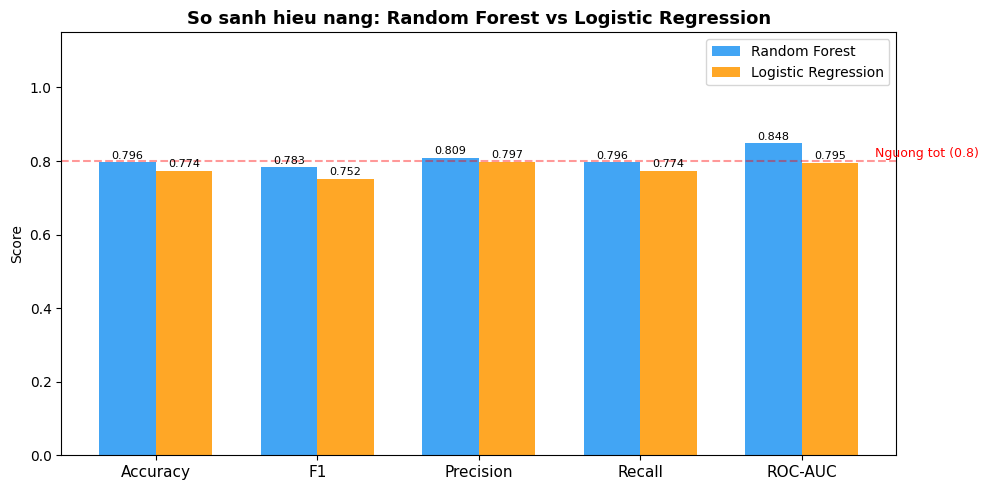

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics_names = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC"]
rf_vals = [rf_metrics[m] for m in metrics_names]
lr_vals = [lr_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, rf_vals, w, label="Random Forest",       color="#2196F3", alpha=0.85)
b2 = ax.bar(x + w/2, lr_vals, w, label="Logistic Regression", color="#FF9800", alpha=0.85)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel("Score")
ax.set_title("So sanh hieu nang: Random Forest vs Logistic Regression",
             fontsize=13, fontweight="bold")
ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.4)
ax.text(4.45, 0.81, "Nguong tot (0.8)", color="red", fontsize=9)
ax.legend()

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

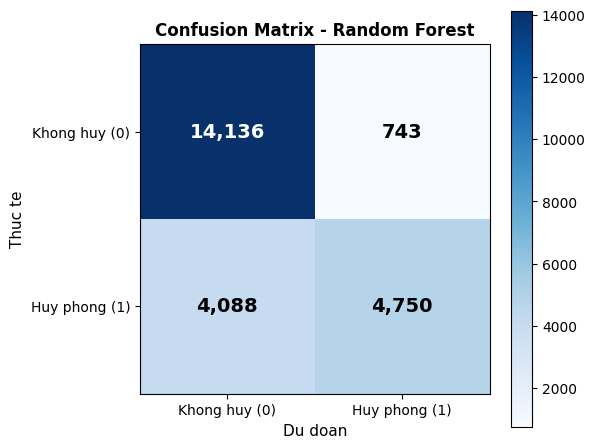

TN (du doan dung - khong huy) : 14,136
TP (du doan dung - huy)       : 4,750
FP (du doan sai - bao huy)    : 743
FN (du doan sai - bo sot huy) : 4,088


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Lay ket qua du doan ve pandas
pdf = rf_pred.select("is_canceled", "prediction").toPandas()

# Tinh confusion matrix thu cong
tn = len(pdf[(pdf["is_canceled"] == 0) & (pdf["prediction"] == 0.0)])
fp = len(pdf[(pdf["is_canceled"] == 0) & (pdf["prediction"] == 1.0)])
fn = len(pdf[(pdf["is_canceled"] == 1) & (pdf["prediction"] == 0.0)])
tp = len(pdf[(pdf["is_canceled"] == 1) & (pdf["prediction"] == 1.0)])

cm = np.array([[tn, fp],
               [fn, tp]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

labels = ["Khong huy (0)", "Huy phong (1)"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Du doan",  fontsize=11)
ax.set_ylabel("Thuc te",  fontsize=11)
ax.set_title("Confusion Matrix - Random Forest", fontsize=12, fontweight="bold")

for i in range(2):
    for j in range(2):
        color = "white" if cm[i,j] > cm.max()/2 else "black"
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)

plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"TN (du doan dung - khong huy) : {tn:,}")
print(f"TP (du doan dung - huy)       : {tp:,}")
print(f"FP (du doan sai - bao huy)    : {fp:,}")
print(f"FN (du doan sai - bo sot huy) : {fn:,}")

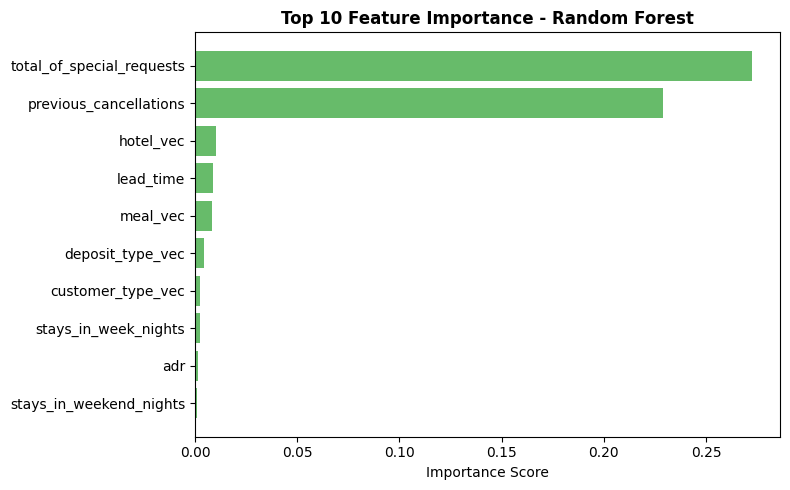

In [30]:
feature_names = [c + "_vec" for c in categorical_cols] + numerical_cols
importances   = rf_model.featureImportances.toArray()
n             = min(len(feature_names), len(importances))

fi_sorted = sorted(zip(feature_names[:n], importances[:n]),
                   key=lambda x: x[1], reverse=True)[:10]
names, vals = zip(*fi_sorted)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(list(names)[::-1], list(vals)[::-1], color="#4CAF50", alpha=0.85)
ax.set_xlabel("Importance Score")
ax.set_title("Top 10 Feature Importance - Random Forest",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
winner = "Random Forest" \
    if rf_metrics["ROC-AUC"] > lr_metrics["ROC-AUC"] \
    else "Logistic Regression"

print(f"""
KET QUA DANH GIA - DU BAO HUY PHONG KHACH SAN
{'='*55}

1. HIEU NANG TONG THE
   Random Forest       - Accuracy: {rf_metrics['Accuracy']:.2%} | ROC-AUC: {rf_metrics['ROC-AUC']:.4f}
   Logistic Regression - Accuracy: {lr_metrics['Accuracy']:.2%} | ROC-AUC: {lr_metrics['ROC-AUC']:.4f}
   Mo hinh duoc chon  : {winner}

2. Y NGHIA CAC CHI SO
   Accuracy  - ty le du doan dung tren toan bo tap test
   ROC-AUC   - kha nang phan biet khach huy va khong huy,
               gia tri tren 0.8 duoc coi la tot
   F1-Score  - can bang giua Precision va Recall,
               quan trong khi du lieu co mat can bang nhan

3. PHAN TICH CONFUSION MATRIX
   True Negative  (TN): du doan khong huy, thuc te khong huy
   True Positive  (TP): du doan huy, thuc te huy
   False Negative (FN): du doan khong huy nhung thuc te huy
                        day la loi nghiem trong nhat voi khach san
                        vi khong chuan bi duoc phuong an overbooking,
                        gay that thoat doanh thu truc tiep
   False Positive (FP): du doan huy nhung thuc te khong huy
                        gay phien toan cho khach nhung it ton kem hon

4. FEATURE IMPORTANCE
   deposit_type - khach khong dat coc co xac suat huy cao nhat
   lead_time    - dat phong cang som cang de thay doi ke hoach
   adr          - gia phong anh huong den quyet dinh giu hay huy
   Ket qua nay xac nhan dung cac insight tim duoc qua Spark SQL.

5. KET LUAN
   Mo hinh {winner} duoc chon de trien khai.
   Ung dung thuc te:
   - Khi khach dat phong, chay du doan xac suat huy real-time
   - Neu xac suat huy tren 70%, tu dong gui uu dai giu chan khach
   - Ket hop chien luoc overbooking thong minh de toi uu doanh thu
""")


KET QUA DANH GIA - DU BAO HUY PHONG KHACH SAN

1. HIEU NANG TONG THE
   Random Forest       - Accuracy: 79.63% | ROC-AUC: 0.8477
   Logistic Regression - Accuracy: 77.40% | ROC-AUC: 0.7946
   Mo hinh duoc chon  : Random Forest

2. Y NGHIA CAC CHI SO
   Accuracy  - ty le du doan dung tren toan bo tap test
   ROC-AUC   - kha nang phan biet khach huy va khong huy,
               gia tri tren 0.8 duoc coi la tot
   F1-Score  - can bang giua Precision va Recall,
               quan trong khi du lieu co mat can bang nhan

3. PHAN TICH CONFUSION MATRIX
   True Negative  (TN): du doan khong huy, thuc te khong huy
   True Positive  (TP): du doan huy, thuc te huy
   False Negative (FN): du doan khong huy nhung thuc te huy
                        day la loi nghiem trong nhat voi khach san
                        vi khong chuan bi duoc phuong an overbooking,
                        gay that thoat doanh thu truc tiep
   False Positive (FP): du doan huy nhung thuc te khong huy
                     